In [15]:
# Initialize Otter
import otter
grader = otter.Notebook("Consolidation_Settlement_notebook.ipynb")

# CEE 175: Geotechnical and Geoenvironmental Engineering

> **Alex Frantzis** <br> Cool Student >:3, UC Berkeley

[![License](https://img.shields.io/badge/license-CC%20BY--NC--ND%204.0-blue)](https://creativecommons.org/licenses/by-nc-nd/4.0/)
***

In this assignment, we will model the time-dependent settlement of a saturated clay layer subjected to an applied load. We will implement **Terzaghi's one-dimensional consolidation theory** using the **finite difference method (FDM)** to numerically solve the consolidation equation, track the dissipation of excess pore water pressure over time, and calculate settlement as a function of time.

In [16]:
# Please run this cell, and do not modify the contents

import hashlib
def get_hash(num):
    """Helper function for assessing correctness"""
    return hashlib.md5(str(num).encode()).hexdigest()
    
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

---
## Background: Consolidation Settlement

### What is Consolidation?

When a load is applied to a saturated fine-grained soil (clay or silt), the sudden increase in stress is initially carried entirely by the **pore water**, not the soil skeleton. This is because water is nearly incompressible and cannot instantly escape from the voids. The resulting pressure above the static water pressure is called **excess pore water pressure**, $u_e$.

Over time, as water gradually drains out of the soil voids, the excess pore pressure **dissipates** and the load transfers progressively to the **soil skeleton** as effective stress. This time-dependent process of drainage, effective stress increase, and volume reduction is called **primary consolidation**.

The surface settles as the soil compresses. The rate at which this happens depends on:
- How easily water can flow through the soil (**permeability**, $k$)
- How compressible the soil is (**coefficient of volume compressibility**, $m_v$)
- The drainage path length (**drainage boundary conditions**)

---

### Terzaghi's 1D Consolidation Equation

For a fully saturated, homogeneous clay layer under a uniform load, Terzaghi derived the following **partial differential equation (PDE)** governing the spatial and temporal evolution of excess pore water pressure $u_e(z, t)$:

$$
c_v \frac{\partial^2 u_e}{\partial z^2} = \frac{\partial u_e}{\partial t}
$$

where the **coefficient of consolidation** is:

$$
c_v = \frac{k}{m_v \, \gamma_w}
$$

$$
\begin{aligned}
\text{where:} \\
u_e &= \text{excess pore water pressure (kPa)} \\
c_v &= \text{coefficient of consolidation (m}^2\text{/yr or m}^2\text{/s)} \\
k   &= \text{hydraulic conductivity (m/s)} \\
m_v &= \text{coefficient of volume compressibility (m}^2\text{/kN)} \\
\gamma_w &= \text{unit weight of water (kN/m}^3\text{)}
\end{aligned}
$$

This is the same form as the **heat equation** from physics — a classic diffusion PDE. The pore pressure "diffuses" out of the soil layer over time, just as heat diffuses out of a heated body.

---

### The Finite Difference Method (FDM)

The **finite difference method** is a numerical technique for approximating derivatives. The core idea is simple: instead of the infinitesimally small $dt$ from calculus, use a small but **finite** time step $\Delta t$.

The derivative $\frac{df}{dt}$ is approximated by:

$$
\frac{df}{dt} \approx \frac{f^{n+1} - f^n}{\Delta t}
$$

where $f^n = f(t_n)$ is the known value at the current time step, and $f^{n+1} = f(t_n + \Delta t)$ is the unknown at the next step. This is called the **explicit** (or **forward**) difference because the right-hand side uses only information already known at step $n$.

Rearranging to solve for the unknown at the next step:

$$
f^{n+1} = f^n + \Delta t \cdot \left.\frac{df}{dt}\right|_n
$$

Starting from an initial condition $f^0$, this rule is applied repeatedly — each step uses the previous result to march the solution forward in time.

---

### Warm-up: Approximating $e^t$ with FDM

The exponential function $f(t) = e^{\lambda t}$ satisfies the ODE:

$$
\frac{df}{dt} = \lambda \cdot f, \qquad f(0) = 1
$$

Substituting the forward difference approximation for the derivative:

$$
\frac{f^{n+1} - f^n}{\Delta t} = \lambda \cdot f^n
$$

Solving for $f^{n+1}$:

$$
\boxed{f^{n+1} = f^n + \lambda \cdot \Delta t \cdot f^n}
$$

Starting from $f^0 = 1$, applying this rule repeatedly at each time step approximates $e^{\lambda t}$. The smaller $\Delta t$ is, the more closely the approximation tracks the exact solution — as we will see in the exercise below.

## Question 0: Approximating the Exponential Function

Write a function named `approxExp()` that uses the explicit finite difference update rule derived above to approximate $f(t) = e^{\lambda t}$.

### Input arguments
- `lambda_val` — the growth rate $\lambda$
- `t_max` — the end time of the simulation
- `dt` — the time step size $\Delta t$

### Output
- `t` — NumPy array of time values from $0$ to `t_max` (inclusive) with spacing `dt`
- `f` — NumPy array of the approximated values of $e^{\lambda t}$ at each time step

---
```python
Examples (lambda_val=1):

>>> t, f = approxExp(1, 1.0, 0.5)
>>> f
[1.0, 1.5, 2.25]          # exact e^1.0 ≈ 2.718

>>> t, f = approxExp(1, 2.0, 0.5)
>>> f
[1.0, 1.5, 2.25, 3.375, 5.0625]   # exact e^2.0 ≈ 7.389
```
---
**Hint:** Use `np.arange(0, t_max + dt/2, dt)` to generate the time array. The `dt/2` offset prevents floating-point rounding from accidentally dropping the final point.

In [17]:
def approxExp(lambda_val, t_max, dt):
    # Create time array from 0 to t_max (inclusive)
    t = np.arange(0, t_max + dt/2, dt)

    # Initialize solution array with zeros
    f = np.zeros(len(t))

    # Set the initial condition: f(0) = e^0 = 1
    f[0] = 1.0  # SOLUTION

    # March forward in time using the explicit FD update rule
    for n in range(len(t) - 1):
        f[n+1] = f[n] + lambda_val * f[n] * dt  # SOLUTION

    return t, f

Set `lambda_val`, `t_max`, and `dt` in the cell below, then run it to see how well the finite difference approximation tracks $e^{\lambda t}$. Try starting with a large $\Delta t$ and making it progressively smaller — what happens to the approximation?

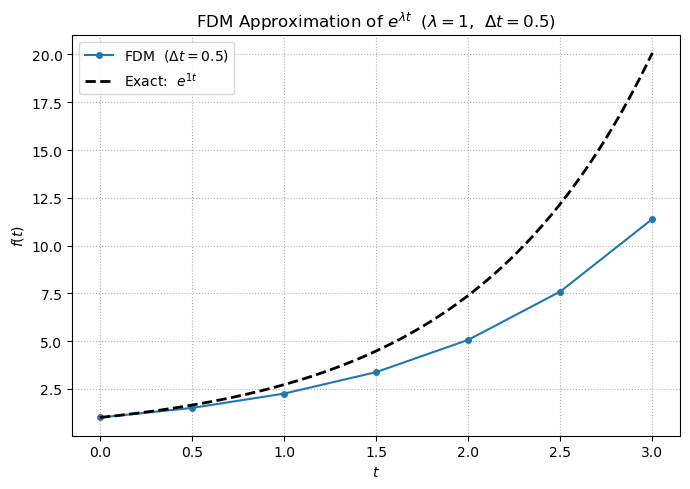

FDM final value:  11.39062
Exact e^(1×3.0):  20.08554
Error:            8.69491


In [18]:
# --- Set your parameters here and run the cell ---

# growth rate λ
lambda_val = 1 # SOLUTION

# end time
t_max      = 3.0  # SOLUTION

# time step Δt
dt         = 0.5  # SOLUTION

#Do not change q0_t and q0_f. These variables are used for testing.
q0_t, q0_f = approxExp(lambda_val, t_max, dt)

# --- Plot FDM result vs exact solution ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(q0_t, q0_f, 'o-', markersize=4, label=f"FDM  ($\\Delta t={dt}$)")

t_exact = np.linspace(0, t_max, 300)
ax.plot(t_exact, np.exp(lambda_val * t_exact), 'k--', linewidth=2,
        label=f"Exact:  $e^{{{lambda_val}t}}$")

ax.set_xlabel("$t$")
ax.set_ylabel("$f(t)$")
ax.set_title(f"FDM Approximation of $e^{{\\lambda t}}$  ($\\lambda={lambda_val}$,  $\\Delta t={dt}$)")
ax.legend()
ax.grid(True, linestyle=":", linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"FDM final value:  {q0_f[-1]:.5f}")
print(f"Exact e^({lambda_val}×{t_max}):  {np.exp(lambda_val * t_max):.5f}")
print(f"Error:            {abs(q0_f[-1] - np.exp(lambda_val * t_max)):.5f}")

In [19]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to test your function!
""" # END TEST CONFIG

# Check the student ran their function
assert get_hash(type(q0_t)) != '14e736438b115821cbb9b7ac0ba79034'
assert get_hash(type(q0_f)) != '14e736438b115821cbb9b7ac0ba79034'

In [20]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Check your initial condition — f[0] should be 1.0.
success_message: Initial condition is correct!
""" # END TEST CONFIG

# Initial condition must be 1.0 regardless of inputs
_t, _f = approxExp(1, 2.0, 0.5)
assert np.isclose(_f[0], 1.0), "f[0] should be 1.0 (since e^0 = 1)"

In [21]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Your update rule is incorrect — check the FD formula for f[n+1].
success_message: Update rule is correct!
""" # END TEST CONFIG

# With lambda=1, dt=0.5: each step multiplies by (1 + 0.5) = 1.5
# So f = [1.0, 1.5, 2.25, 3.375, 5.0625] for t_max=2.0
_t, _f = approxExp(1, 2.0, 0.5)
assert np.isclose(_f[1], 1.5),    "After 1 step (lambda=1, dt=0.5): f[1] should be 1.5"
assert np.isclose(_f[2], 2.25),   "After 2 steps (lambda=1, dt=0.5): f[2] should be 2.25"
assert np.isclose(_f[4], 5.0625), "After 4 steps (lambda=1, dt=0.5): f[4] should be 5.0625"

In [22]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Check that your function works correctly for different lambda values and step sizes.
success_message: Function handles varying inputs correctly!
""" # END TEST CONFIG

# lambda=2, dt=0.25: each step multiplies by (1 + 2*0.25) = 1.5
# After 4 steps to t=1.0: f[-1] = 1.5^4 = 5.0625
_t, _f = approxExp(2, 1.0, 0.25)
assert np.isclose(_f[-1], 1.5**4), "With lambda=2, dt=0.25, t_max=1.0: f[-1] should be 1.5^4"

# Check time array length is correct: t = [0, dt, 2*dt, ..., t_max]
_t2, _f2 = approxExp(1, 3.0, 0.1)
assert len(_t2) == len(_f2), "t and f arrays must be the same length"
assert np.isclose(_t2[0], 0.0),  "t[0] should be 0.0"
assert np.isclose(_t2[-1], 3.0), "t[-1] should equal t_max"

---
## Stability in Finite Difference Methods

The FDM gets more accurate as $\Delta t$ decreases — but can we always make $\Delta t$ as large as we want and still get a reasonable result? It turns out, no.

To see why, let's apply the same `approxExp` function to a **decaying** exponential: $f(t) = e^{-t}$, by setting $\lambda = -1$. The exact solution smoothly decays from 1 toward 0. The FDM update rule becomes:

$$f^{n+1} = f^n + (-1) \cdot \Delta t \cdot f^n = f^n\,(1 - \Delta t)$$

Each step multiplies the current value by the **amplification factor** $(1 - \Delta t)$:

A numerical method is called **stable** if errors remain bounded over time. For this problem, stability requires:

$$|1 - \Delta t| \leq 1 \quad\Longrightarrow\quad \Delta t \leq 2$$

Use the slider in the cell below to explore. Pay attention to what changes as you cross $\Delta t = 2$

In [23]:
import ipywidgets as widgets
from ipywidgets import interact

def plot_stability(dt):
    lambda_val = -1
    t_max = 20

    t_fdm, f_fdm = approxExp(lambda_val, t_max, dt)
    t_exact = np.linspace(0, t_max, 400)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(t_exact, np.exp(lambda_val * t_exact), 'k--', linewidth=2, label="Exact: $e^{-t}$")
    ax.plot(t_fdm, f_fdm, 'o-', markersize=5, label=f"FDM ($\\Delta t = {dt:.2f}$)")
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

    ax.set_xlabel("$t$")
    ax.set_ylabel("$f(t)$")
    ax.set_title(f"FDM Stability:  $f' = -f$   ($\\Delta t = {dt:.2f}$)")
    ax.legend()
    ax.grid(True, linestyle=":", linewidth=0.8)
    plt.tight_layout()
    plt.show()

    amp = abs(1 + lambda_val * dt)   # = |1 - dt|
    status = "Stable ✓" if amp <= 1 else "UNSTABLE ✗"
    print(f"Amplification factor  |1 − Δt| = {amp:.3f}   →   {status}")

interact(plot_stability,
         dt=widgets.FloatSlider(value=0.5, min=0.05, max=2.5, step=0.05,
                                description='Δt:', continuous_update=False,
                                style={'description_width': 'initial'},
                                layout=widgets.Layout(width='520px')))

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='Δt:', layout=Layout(width='…

<function __main__.plot_stability(dt)>

## Question 1: Interlude — Heat Diffusion in a Rod

> **Note:** This question is a deliberate detour from geotechnics. The goal is to get comfortable with the central data structure required for all finite difference PDE problems: a **2D array that represents a value at every point in space *and* every point in time simultaneously**. The physics here are intentionally simple so the focus stays on the method. Once this feels natural, the consolidation problem in the next questions is just a change of variables.

---

### Adding a Second Dimension: Space

In Question 0, we tracked a single scalar $f(t)$ evolving in time — a purely 1D problem. The consolidation PDE is more involved: excess pore pressure $u_e$ varies in both **depth** $z$ *and* **time** $t$. To solve it numerically we must discretize both directions and store the result in a 2D grid.

We divide space into $N_z$ evenly-spaced nodes and time into $N_t$ steps, then pack all the values into a single NumPy array:

$$T[\,n,\; i\,] \;=\; \text{temperature at time step } n \text{ and spatial node } i$$

**Rows index time. Columns index space.** Reading a single row gives a snapshot of the entire rod at one instant; reading a single column traces one point through all of time. This is the key mental model — everything else follows from it.

---

### The Heat Equation (same math as consolidation, more tangible physics)

The **1D heat equation** governs how temperature spreads along a thin rod:

$$\frac{\partial T}{\partial t} = \alpha \, \frac{\partial^2 T}{\partial x^2}$$

This equation is **identical in form** to Terzaghi's consolidation PDE — just with $T \to u_e$ and $\alpha \to c_v$. The physics differ, but the mathematics (and the code) are exactly the same.

**Scenario:** A rod of length $L = 1\,\text{m}$ starts at a uniform temperature $T_0 = 100°\text{C}$. At $t = 0$, both ends are suddenly held at $T = 0°\text{C}$ (imagine plunging them into ice water). How does the temperature profile evolve?

---

### Explicit FD Discretization (FTCS)

Applying a **forward difference in time** and a **central difference in space**:

$$\frac{T_i^{n+1} - T_i^n}{\Delta t} = \alpha \, \frac{T_{i+1}^n - 2T_i^n + T_{i-1}^n}{\Delta z^2}$$

Rearranging to solve for the only unknown $T_i^{n+1}$:

$$\boxed{T_i^{n+1} = T_i^n + r\!\left(T_{i+1}^n - 2T_i^n + T_{i-1}^n\right)}, \qquad r = \frac{\alpha \, \Delta t}{\Delta z^2}$$

The update rule says: the temperature at node $i$ at the next time step equals its current value, adjusted by how much it differs from its neighbors — i.e., proportional to the **curvature** of the temperature profile.

The parameter $r$ controls the size of that adjustment. From the stability analysis in the previous section, the explicit scheme is only stable when:

$$r \leq 0.5$$

---

### Your Task

The function `heatRod()` below is almost entirely written for you. **Your only job is to fill in the single update line inside the time-stepping loop.** Then run the exploration cell and spend a few minutes playing with the parameters — in particular, try pushing $r$ above $0.5$ and observe what happens.

In [24]:
def heatRod(alpha, L, T0, t_max, Nz, r):
    """
    Simulate heat diffusion in a 1D rod using the explicit (FTCS) finite difference method.

    Parameters
    ----------
    alpha : float   Thermal diffusivity
    L     : float   Rod length (m)
    T0    : float   Uniform initial temperature (°C)
    t_max : float   End time of the simulation
    Nz    : int     Number of spatial nodes, including both boundary endpoints
    r     : float   Stability parameter  r = alpha * dt / dz²   (must be ≤ 0.5)

    Returns
    -------
    z : ndarray, shape (Nz,)      spatial positions
    t : ndarray, shape (Nt,)      time values
    T : ndarray, shape (Nt, Nz)   T[n, i] = temperature at time step n, spatial node i
    """
    # ── Grid setup ────────────────────────────────────────────────────────────
    dz = L / (Nz - 1)           # spatial step size
    dt = r * dz**2 / alpha      # time step derived from the chosen r value
    Nt = int(t_max / dt) + 1    # total number of time steps

    z = np.linspace(0, L, Nz)  # Nz evenly-spaced nodes from 0 to L
    t = np.arange(Nt) * dt      # time grid

    # ── Solution array ───────────────────────────────────────────────────────
    # T[n, i] = temperature at time step n and spatial node i.
    # Shape: (Nt rows) × (Nz columns)  →  rows = time, columns = space.
    T = np.zeros((Nt, Nz))

    # ── Initial condition ─────────────────────────────────────────────────────
    # At t = 0, the entire rod (including interior) is at T0.
    T[0, :] = T0

    # ── Boundary conditions ───────────────────────────────────────────────────
    # Both ends are held at 0°C for all time.
    # Setting entire columns here ensures the loop can never accidentally
    # overwrite these values.
    T[:, 0]  = 0.0   # left  end  (x = 0)
    T[:, -1] = 0.0   # right end  (x = L)

    # ── Time-stepping loop ────────────────────────────────────────────────────
    for n in range(Nt - 1):
        # Update every interior node (i = 1 … Nz-2) in one vectorized step.
        #
        #   T[n, 1:-1]  →  current values at interior nodes
        #   T[n, 2:]    →  right neighbors  (i + 1)
        #   T[n, :-2]   →  left  neighbors  (i - 1)
        #
        # Fill in the explicit FD update rule:
        #   T[n+1, i] = T[n, i] + r * (T[n, i+1] - 2*T[n, i] + T[n, i-1])
        T[n+1, 1:-1] = T[n, 1:-1] + r * (T[n, 2:] - 2*T[n, 1:-1] + T[n, :-2])  # SOLUTION

    return z, t, T

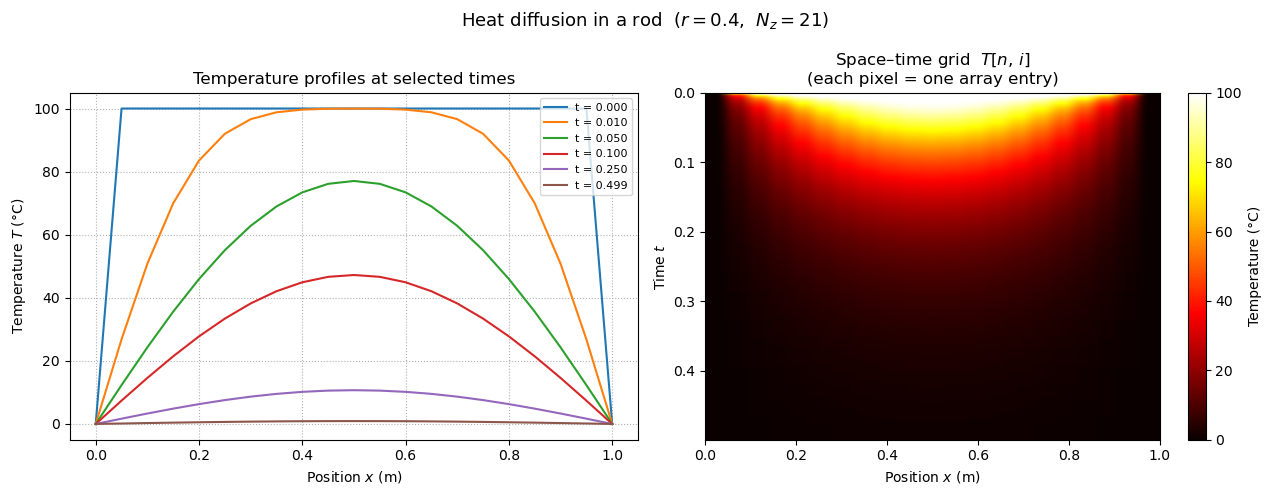

Grid:  Nz = 21,  Nt = 500,  dz = 0.0500,  dt = 0.001000
Stability:  r = 0.4  →  STABLE  ✓


In [25]:
# ── Try changing these parameters and re-running the cell ────────────────────
alpha = 1.0    # thermal diffusivity (normalized)
L     = 1.0    # rod length (m)
T0    = 100.0  # initial temperature (°C)
t_max = 0.5    # end time of simulation
Nz    = 21     # number of spatial nodes — try 11, 21, 41
r     = 0.4    # stability parameter — try 0.4, then 0.48, then 0.51!

# ── Run the simulation ────────────────────────────────────────────────────────
q1_z, q1_t, q1_T = heatRod(alpha, L, T0, t_max, Nz, r)

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: temperature profiles (one curve per time snapshot)
snapshot_times = [0.0, 0.01, 0.05, 0.1, 0.25, t_max]
for t_snap in snapshot_times:
    idx = np.argmin(np.abs(q1_t - t_snap))
    axes[0].plot(q1_z, q1_T[idx, :], label=f"t = {q1_t[idx]:.3f}")
axes[0].set_xlabel("Position $x$ (m)")
axes[0].set_ylabel("Temperature $T$ (°C)")
axes[0].set_title("Temperature profiles at selected times")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle=":", linewidth=0.8)

# Right: the full T[n, i] array as an image — rows = time, columns = space
im = axes[1].imshow(q1_T, aspect='auto', origin='upper',
                    extent=[0, L, q1_t[-1], 0],
                    cmap='hot', vmin=0, vmax=T0)
plt.colorbar(im, ax=axes[1], label="Temperature (°C)")
axes[1].set_xlabel("Position $x$ (m)")
axes[1].set_ylabel("Time $t$")
axes[1].set_title("Space–time grid  $T[n,\\,i]$\n(each pixel = one array entry)")

plt.suptitle(f"Heat diffusion in a rod  ($r = {r}$,  $N_z = {Nz}$)", fontsize=13)
plt.tight_layout()
plt.show()

dz = q1_z[1] - q1_z[0]
dt = q1_t[1] - q1_t[0] if len(q1_t) > 1 else 0.0
print(f"Grid:  Nz = {Nz},  Nt = {len(q1_t)},  dz = {dz:.4f},  dt = {dt:.6f}")
print(f"Stability:  r = {r}  →  {'STABLE  ✓' if r <= 0.5 else 'UNSTABLE  ✗  (values will blow up!)'}")

In [26]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to run the heatRod simulation cell above!
""" # END TEST CONFIG

assert get_hash(type(q1_T)) != '14e736438b115821cbb9b7ac0ba79034'
assert get_hash(type(q1_z)) != '14e736438b115821cbb9b7ac0ba79034'
assert get_hash(type(q1_t)) != '14e736438b115821cbb9b7ac0ba79034'

In [27]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Check the initial condition (T[0, :] = T0) and boundary conditions (T[:, 0] = T[:, -1] = 0) inside heatRod().
success_message: Initial and boundary conditions are set correctly!
""" # END TEST CONFIG

_z, _t, _T = heatRod(1.0, 1.0, 100.0, 0.1, 11, 0.4)

# Initial condition: all interior nodes at t=0 should equal T0
assert np.allclose(_T[0, 1:-1], 100.0), \
    "Interior nodes at t=0 should equal T0=100"

# Boundary conditions: both ends must be 0 for all time
assert np.allclose(_T[:, 0],  0.0), "Left boundary T[:, 0] must be 0 for all time"
assert np.allclose(_T[:, -1], 0.0), "Right boundary T[:, -1] must be 0 for all time"

In [28]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Your FD update rule is incorrect — check the formula T[n+1, 1:-1] = T[n, 1:-1] + r*(T[n, 2:] - 2*T[n, 1:-1] + T[n, :-2]).
success_message: Update rule is correct — the explicit FD scheme is working!
""" # END TEST CONFIG

_z, _t, _T = heatRod(1.0, 1.0, 100.0, 0.1, 11, 0.4)

# With r=0.4, T0=100, dz=0.1, after ONE time step at node i=1:
#   T[1, 1] = 100 + 0.4*(100 - 2*100 + 0) = 100 - 40 = 60
assert np.isclose(_T[1, 1], 60.0), \
    f"After 1 step, T[1,1] should be 60.0 (= T0*(1-r) = 100*0.6); got {_T[1,1]}"

# Center node at step 1: all neighbors are equal, curvature = 0, no change
assert np.isclose(_T[1, 5], 100.0), \
    f"After 1 step, center node T[1,5] should still be 100.0; got {_T[1,5]}"

# The rod is symmetric, so T[n, i] == T[n, Nz-1-i] for all n, i
assert np.allclose(_T, _T[:, ::-1]), \
    "Temperature field should be symmetric about the rod's center"

## Question 2: Consolidation Settlement Using the Explicit Finite Difference Method

### Problem Description

A **10-foot thick sand stratum** overlies a **30-foot thick normally consolidated clay layer**, which is underlain by a **40-foot thick dense sand deposit**. The water table is 4 ft below the ground surface.

| Layer | Depth (ft) | Properties |
|---|---|---|
| Upper sand | 0 – 10 | $\gamma = 127$ pcf above WT; $\;\gamma = 130$ pcf below WT |
| Clay | 10 – 40 | $w = 80\%$, $G_s = 2.76$, $LL = 90\%$, normally consolidated |
| Lower dense sand | 40 + | Permeable |

A **laterally wide 15-ft layer of compacted fill** ($\gamma_\text{fill} = 132$ pcf) is placed uniformly over the site. Because the fill is wide in every horizontal direction, horizontal drainage can be neglected and this is a purely **1D consolidation** problem. The applied stress increment is:

$$\Delta\sigma = 15\ \text{ft} \times 132\ \text{pcf} = 1{,}980\ \text{psf}$$

For a saturated clay under a sudden load, **all of $\Delta\sigma$ is initially carried as excess pore water pressure** — the soil skeleton cannot accept load until water has time to drain:

$$u_e(z,\, 0) = \Delta\sigma = 1{,}980\ \text{psf} \qquad \text{(uniform across the full clay thickness at } t = 0^+\text{)}$$

The coefficient of consolidation (derived from a doubly-drained lab specimen, $H = 0.987$ in, $t_{50} = 8.4$ min) is given as:

$$c_v = 20.8\ \text{ft}^2\text{/yr}$$

---

### Boundary Conditions — What Happens at the Clay Faces?

Before writing any code we need to specify what value $u_e$ takes at the **top** and **bottom** of the clay layer for all $t > 0$. The physical conditions at each interface determine which type of boundary condition applies.

**Drained boundary — Dirichlet condition: $u_e = 0$**

When clay contacts a highly permeable layer (sand, gravel), water escapes freely the moment excess pressure develops. That boundary node remains in equilibrium with the hydrostatic condition, so:

$$u_e(\text{boundary},\ t) = 0 \qquad \text{for all } t > 0$$

In code this means setting an entire column of `ue` to zero — identical to what was done for the ends of the heat rod in Question 1.

**Impermeable boundary — Neumann condition: $\partial u_e / \partial z = 0$**

When clay rests against an impermeable material (bedrock, an undrained stratum), no water can cross that face. The hydraulic gradient must vanish there. Implementing this requires a **ghost node**: a virtual point just outside the domain whose value mirrors the adjacent interior value, $u_e[n, N_z] = u_e[n, N_z-2]$. This changes the update at that node to:

$$u_{N-1}^{n+1} = u_{N-1}^n + 2r\!\left(u_{N-2}^n - u_{N-1}^n\right)$$

**This problem:** Both the upper sand and lower dense sand drain freely, so **both clay faces are drained (Dirichlet)** — this is a **doubly-drained** layer with drainage path $H_{dr} = H/2 = 15$ ft. No ghost nodes are needed. The setup is identical to the heat rod from Question 1, with both ends held at zero.

---

### Your Tasks

**(a)–(d)** Using `consolidateFDM()` below, compute and plot $u_e$ versus depth on a single figure at:
$\quad t = 0$ yr (immediately after loading), $t = 1$ yr, $t = 5$ yr, and $t = 10$ yr.

**(e)** Using the Terzaghi analytical solution provided in the comparison cell, compare your FDM values of $u_e$ at $t = 5$ yr against the analytical result at depths of **15 ft** and **25 ft** below the original ground surface. How close are the two methods?

---

The function `consolidateFDM()` below is structured identically to `heatRod()` from Question 1. The variable substitutions are $T \to u_e$, $\alpha \to c_v$, and $T_0 \to \Delta\sigma$. **Fill in the single FD update rule** — the same line you already wrote in Question 1.

In [29]:
# ── Problem parameters (given) ────────────────────────────────────────────────
cv          = 20.8    # coefficient of consolidation (ft²/yr)
H           = 30.0    # clay layer thickness (ft)
delta_sigma = 1980.0  # applied stress increment: 15 ft × 132 pcf (psf)
z_clay_top  = 10.0    # depth to top of clay below ground surface (ft)

# ── FDM grid parameters ───────────────────────────────────────────────────────
Nz    = 31     # spatial nodes  →  dz = H / (Nz-1) = 1 ft
r     = 0.4    # stability parameter (must be ≤ 0.5)
t_max = 10.0   # simulate 10 years

In [30]:
def consolidateFDM(cv, H, delta_sigma, t_max, Nz, r):
    """
    Simulate 1D consolidation (dissipation of excess pore pressure) in a
    doubly-drained clay layer using the explicit (FTCS) finite difference method.

    This function is identical in structure to heatRod() from Question 1.
    Substitutions:  T → ue,  alpha → cv,  T0 → delta_sigma.

    Parameters
    ----------
    cv          : float   Coefficient of consolidation (ft²/yr)
    H           : float   Clay layer thickness (ft)
    delta_sigma : float   Initial uniform excess pore pressure = applied Δσ (psf)
    t_max       : float   End time of simulation (yr)
    Nz          : int     Number of spatial nodes (including both boundary nodes)
    r           : float   Stability parameter  r = cv·dt/dz²  (must be ≤ 0.5)

    Returns
    -------
    z  : (Nz,)     depth within clay layer (ft);  z=0 at top,  z=H at bottom
    t  : (Nt,)     time array (yr)
    ue : (Nt, Nz)  ue[n, i] = excess pore pressure at time n, depth node i (psf)
    """
    # ── Grid setup ────────────────────────────────────────────────────────────
    dz = H / (Nz - 1)
    dt = r * dz**2 / cv
    Nt = int(t_max / dt) + 1

    z  = np.linspace(0, H, Nz)
    t  = np.arange(Nt) * dt
    ue = np.zeros((Nt, Nz))

    # ── Initial condition ─────────────────────────────────────────────────────
    # At t = 0⁺, the full applied stress is carried as excess pore pressure.
    ue[0, :] = delta_sigma

    # ── Boundary conditions ───────────────────────────────────────────────────
    # Both clay faces drain into adjacent sand → Dirichlet (ue = 0).
    # This is the same double-Dirichlet setup as the heat rod in Question 1.
    ue[:, 0]  = 0.0   # top of clay  (drains into upper sand)
    ue[:, -1] = 0.0   # bottom of clay (drains into lower dense sand)

    # ── Time-stepping loop ────────────────────────────────────────────────────
    for n in range(Nt - 1):
        # Same update rule as Question 1 — fill in the explicit FD formula:
        #   ue[n+1, i] = ue[n, i] + r * (ue[n, i+1] - 2*ue[n, i] + ue[n, i-1])
        ue[n+1, 1:-1] = ue[n, 1:-1] + r * (ue[n, 2:] - 2*ue[n, 1:-1] + ue[n, :-2])  # SOLUTION

    return z, t, ue

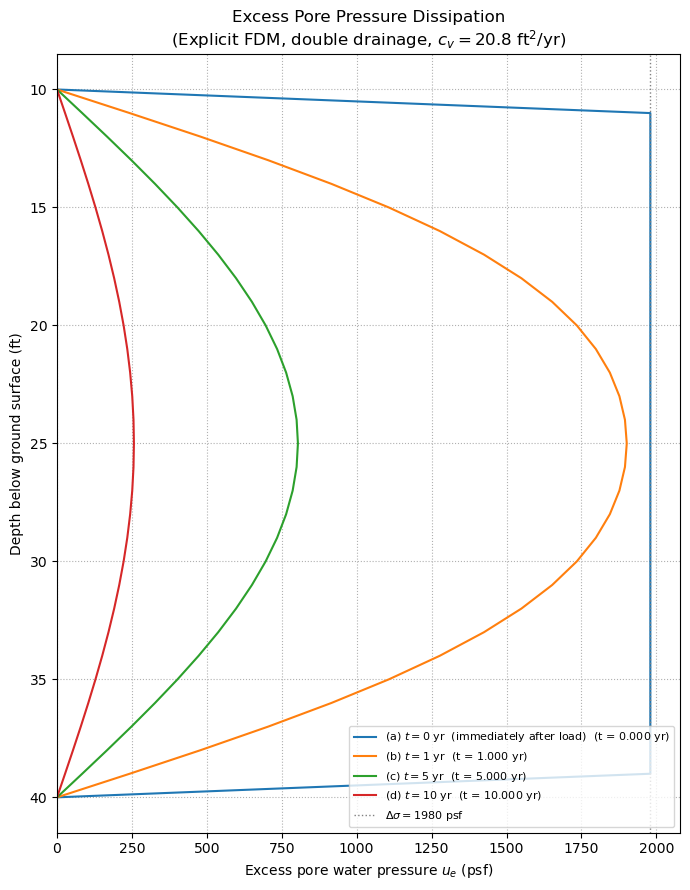

Grid:  Nz = 31,  Nt = 521,  dz = 1.00 ft,  dt = 0.01923 yr
Stability:  r = 0.4  →  STABLE ✓


In [31]:
# ── Run the simulation ────────────────────────────────────────────────────────
q2_z, q2_t, q2_ue = consolidateFDM(cv, H, delta_sigma, t_max, Nz, r)

# Absolute depth below ground surface for y-axis labeling
z_abs = q2_z + z_clay_top   # local clay coord → 10 to 40 ft depth

# ── Plot ue vs depth at the four required times ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 9))

plot_times = [
    ('(a) $t = 0$ yr  (immediately after load)', 0.0),
    ('(b) $t = 1$ yr',                            1.0),
    ('(c) $t = 5$ yr',                            5.0),
    ('(d) $t = 10$ yr',                           10.0),
]
for label, t_snap in plot_times:
    idx = np.argmin(np.abs(q2_t - t_snap))
    ax.plot(q2_ue[idx, :], z_abs, label=f'{label}  (t = {q2_t[idx]:.3f} yr)')

ax.axvline(delta_sigma, color='gray', linestyle=':', linewidth=1.0,
           label=f'$\\Delta\\sigma = {int(delta_sigma)}$ psf')
ax.set_xlabel("Excess pore water pressure $u_e$ (psf)")
ax.set_ylabel("Depth below ground surface (ft)")
ax.set_title("Excess Pore Pressure Dissipation\n"
             r"(Explicit FDM, double drainage, $c_v = 20.8\ \mathrm{ft^2/yr}$)")
ax.invert_yaxis()
ax.set_xlim(left=0)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

dz_val = q2_z[1] - q2_z[0]
dt_val = q2_t[1] - q2_t[0]
print(f"Grid:  Nz = {Nz},  Nt = {len(q2_t)},  dz = {dz_val:.2f} ft,  dt = {dt_val:.5f} yr")
print(f"Stability:  r = {r}  →  {'STABLE ✓' if r <= 0.5 else 'UNSTABLE ✗'}")

In [32]:
# ── Part (e): FDM vs Terzaghi analytical solution ────────────────────────────
#
# For a uniform initial excess pore pressure and double drainage, the Terzaghi
# series solution is (Coduto / Das form):
#
#   ue(z, t) = Σ (2·Δσ / M) · sin(M·z / Hdr) · exp(−M²·Tv)
#
# where  M = (2m+1)π/2,  Tv = cv·t / Hdr²,  and z is measured from
# a drainage face (0 to Hdr).  This function is provided — do not modify it.

def terzaghi_ue(cv, Hdr, delta_sigma, z, t, n_terms=50):
    """Terzaghi series solution — uniform IC, double drainage."""
    Tv = cv * t / Hdr**2
    ue_val = 0.0
    for m in range(n_terms):
        M = (2 * m + 1) * np.pi / 2
        ue_val += (2 * delta_sigma / M) * np.sin(M * z / Hdr) * np.exp(-M**2 * Tv)
    return ue_val

Hdr = H / 2   # drainage path for double drainage = 15 ft

# Comparison points — local clay coordinate (0 = top of clay)
compare_points = {
    'z = 15 ft depth   (5 ft from top of clay)':    5.0,
    'z = 25 ft depth   (15 ft from top, midplane)': 15.0,
}

t_compare = 5.0
idx_t = np.argmin(np.abs(q2_t - t_compare))

print(f"\nPart (e) — Comparison at t = {t_compare} yr\n")
print(f"{'Depth':<44} {'FDM (psf)':>11} {'Terzaghi (psf)':>15} {'Difference':>12}")
print("─" * 84)
for label, z_local in compare_points.items():
    iz      = np.argmin(np.abs(q2_z - z_local))
    fdm_val = q2_ue[idx_t, iz]
    tz_val  = terzaghi_ue(cv, Hdr, delta_sigma, z_local, t_compare)
    diff    = fdm_val - tz_val
    print(f"{label:<44} {fdm_val:>11.1f} {tz_val:>15.1f} {diff:>+11.1f} psf")


Part (e) — Comparison at t = 5.0 yr

Depth                                          FDM (psf)  Terzaghi (psf)   Difference
────────────────────────────────────────────────────────────────────────────────────
z = 15 ft depth   (5 ft from top of clay)          402.0           403.0        -1.0 psf
z = 25 ft depth   (15 ft from top, midplane)       803.9           805.8        -1.9 psf


In [33]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Make sure to run the consolidateFDM simulation cell above!
""" # END TEST CONFIG

assert get_hash(type(q2_ue)) != '14e736438b115821cbb9b7ac0ba79034'
assert get_hash(type(q2_z))  != '14e736438b115821cbb9b7ac0ba79034'
assert get_hash(type(q2_t))  != '14e736438b115821cbb9b7ac0ba79034'

In [34]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Check the initial condition (ue[0, :] = delta_sigma) and boundary conditions (ue[:, 0] = ue[:, -1] = 0) inside consolidateFDM().
success_message: Initial condition and boundary conditions are correct!
""" # END TEST CONFIG

_z, _t, _ue = consolidateFDM(20.8, 30.0, 1980.0, 1.0, 11, 0.4)

# Initial condition: all interior nodes at t=0 equal delta_sigma
assert np.allclose(_ue[0, 1:-1], 1980.0), \
    "Interior nodes at t=0 should equal delta_sigma = 1980 psf"

# Boundary conditions: both drainage faces must remain at 0 for all time
assert np.allclose(_ue[:, 0],  0.0), "Top boundary ue[:, 0] must be 0 for all time"
assert np.allclose(_ue[:, -1], 0.0), "Bottom boundary ue[:, -1] must be 0 for all time"

In [35]:
""" # BEGIN TEST CONFIG
points: 0
failure_message: Your FD update rule is incorrect — use the same formula as in heatRod(): ue[n+1, 1:-1] = ue[n, 1:-1] + r*(ue[n, 2:] - 2*ue[n, 1:-1] + ue[n, :-2]).
success_message: Update rule is correct — consolidation FDM is working!
""" # END TEST CONFIG

_z, _t, _ue = consolidateFDM(20.8, 30.0, 1980.0, 1.0, 11, 0.4)
# Nz=11, H=30  →  dz = 3 ft.  r = 0.4.
# Node i=1 after 1 step:
#   ue[1,1] = 1980 + 0.4*(1980 - 2*1980 + 0) = 1980*(1 - 0.4) = 1188 psf
assert np.isclose(_ue[1, 1], 1188.0), \
    f"After 1 step, ue[1,1] should be 1188.0 psf (= delta_sigma*(1-r)); got {_ue[1,1]:.2f}"

# Midplane node (i=5, z=15 ft): all neighbors equal, curvature = 0, no change
assert np.isclose(_ue[1, 5], 1980.0), \
    f"After 1 step, midplane node ue[1,5] should still be 1980.0 psf; got {_ue[1,5]:.2f}"

# Double drainage + uniform IC → solution must be symmetric about midplane
assert np.allclose(_ue, _ue[:, ::-1]), \
    "Pore pressure field must be symmetric about the midplane for double drainage"